# EDA — Accounts Receivable / Payment Delay

## Objetivo

El objetivo de este análisis exploratorio es determinar si el dataset contiene información suficiente y adecuada para construir un modelo capaz de estimar, en el momento de emisión de una factura, la probabilidad de que sea pagada después de su fecha de vencimiento.

El EDA analizará:

- estructura y calidad del dataset;
- distribución de la variable objetivo;
- representación e histórico disponible por cliente;
- relaciones entre variables y retraso;
- comportamiento temporal;
- valores extremos;
- posibles fugas de información;
- viabilidad de una división temporal para entrenamiento y evaluación.

La unidad de análisis es una factura.

In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import matplotlib.dates as mdates

In [2]:
df = pd.read_csv("../data/raw/accounts_receivable_ibm.csv")

df.head()

,countryCode,customerID,PaperlessDate,invoiceNumber,InvoiceDate,DueDate,InvoiceAmount,Disputed,SettledDate,PaperlessBill,DaysToSettle,DaysLate
0,391,0379-NEVHP,4/6/2013,611365,1/2/2013,2/1/2013,55.94,No,1/15/2013,Paper,13,0
1,406,8976-AMJEO,3/3/2012,7900770,1/26/2013,2/25/2013,61.74,Yes,3/3/2013,Electronic,36,6
2,391,2820-XGXSB,1/26/2012,9231909,7/3/2013,8/2/2013,65.88,No,7/8/2013,Electronic,5,0
3,406,9322-YCTQO,4/6/2012,9888306,2/10/2013,3/12/2013,105.92,No,3/17/2013,Electronic,35,5
4,818,6627-ELFBK,11/26/2012,15752855,10/25/2012,11/24/2012,72.27,Yes,11/28/2012,Paper,34,4


### Dimensiones dataset

In [3]:
print(df.shape)
print(f'numero de columnas: {df.shape[1]}')
df.info()

(2466, 12)
numero de columnas: 12
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2466 entries, 0 to 2465
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   countryCode    2466 non-null   int64  
 1   customerID     2466 non-null   object 
 2   PaperlessDate  2466 non-null   object 
 3   invoiceNumber  2466 non-null   int64  
 4   InvoiceDate    2466 non-null   object 
 5   DueDate        2466 non-null   object 
 6   InvoiceAmount  2466 non-null   float64
 7   Disputed       2466 non-null   object 
 8   SettledDate    2466 non-null   object 
 9   PaperlessBill  2466 non-null   object 
 10  DaysToSettle   2466 non-null   int64  
 11  DaysLate       2466 non-null   int64  
dtypes: float64(1), int64(4), object(7)
memory usage: 231.3+ KB


In [4]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
countryCode,2466.0,NaN,NaN,NaN,620.446067,215.93361,391.0,406.0,770.0,818.0,897.0
customerID,2466,100,9149-MATVB,36,NaN,NaN,NaN,NaN,NaN,NaN,NaN
PaperlessDate,2466,91,3/3/2012,58,NaN,NaN,NaN,NaN,NaN,NaN,NaN
invoiceNumber,2466.0,NaN,NaN,NaN,4978430514.972425,2884271865.47071,611365.0,2528853991.0,4964228313.5,7494512439.0,9990243864.0
InvoiceDate,2466,681,12/30/2012,10,NaN,NaN,NaN,NaN,NaN,NaN,NaN
DueDate,2466,681,1/29/2013,10,NaN,NaN,NaN,NaN,NaN,NaN,NaN
InvoiceAmount,2466.0,NaN,NaN,NaN,59.895856,20.435838,5.26,46.4,60.56,73.765,128.28
Disputed,2466,2,No,1905,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SettledDate,2466,695,4/28/2013,10,NaN,NaN,NaN,NaN,NaN,NaN,NaN
PaperlessBill,2466,2,Paper,1263,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Granularidad

In [5]:
df['invoiceNumber'].nunique() == len(df)

True

In [6]:
df["invoiceNumber"].duplicated().sum()

0

In [7]:
df.duplicated().sum()

0

- Podemos ver que cada fila se asocia a un número de factura distinto, se puede usar como clave primaria en un futuro
- no hay ningún registro duplicado a priori

### Calidad de los datos

##### Valores nulos

In [8]:
missing = df.isna().sum().to_frame("n_null")
missing["pct_null"] = missing['n_null'] / len(df) * 100
missing.sort_values("pct_null", ascending=False)

,n_null,pct_null
countryCode,0,0.0
customerID,0,0.0
PaperlessDate,0,0.0
invoiceNumber,0,0.0
InvoiceDate,0,0.0
DueDate,0,0.0
InvoiceAmount,0,0.0
Disputed,0,0.0
SettledDate,0,0.0
PaperlessBill,0,0.0


##### Valores únicos

In [9]:
df.nunique().sort_values()

Disputed            2
PaperlessBill       2
countryCode         5
DaysLate           37
DaysToSettle       67
PaperlessDate      91
customerID        100
InvoiceDate       681
DueDate           681
SettledDate       695
InvoiceAmount    2098
invoiceNumber    2466
dtype: int64

### Tratamiento y validación de fechas

In [10]:
date_cols = [
    "InvoiceDate",
    "DueDate",
    "SettledDate"
]

for col in date_cols:
    df[col] = pd.to_datetime(df[col], format='%m/%d/%Y', errors='coerce')
    
df[date_cols].isna().sum()

InvoiceDate    0
DueDate        0
SettledDate    0
dtype: int64

In [11]:
print(df[date_cols].dtypes)

display(
    df[
        ["InvoiceDate", "DueDate", "SettledDate"]
    ].head()
)

InvoiceDate    datetime64[ns]
DueDate        datetime64[ns]
SettledDate    datetime64[ns]
dtype: object


,InvoiceDate,DueDate,SettledDate
0,2013-01-02,2013-02-01,2013-01-15
1,2013-01-26,2013-02-25,2013-03-03
2,2013-07-03,2013-08-02,2013-07-08
3,2013-02-10,2013-03-12,2013-03-17
4,2012-10-25,2012-11-24,2012-11-28


In [12]:
# Comprobamos si hay entregas anteriores a la fecha de factura
(df["DueDate"] < df["InvoiceDate"]).sum()

0

In [13]:
# Comprobamos si hay pagos anteriores o anticipados a la fecha de factura
(df["SettledDate"] < df["InvoiceDate"]).sum()

0

##### Rangos temporales

In [14]:
# Rango temportal de facturas emitidas
df["InvoiceDate"].min(), df["InvoiceDate"].max()

(Timestamp('2012-01-03 00:00:00'), Timestamp('2013-12-02 00:00:00'))

In [15]:
# Rango temporal de pagos
df["SettledDate"].min(), df["SettledDate"].max()

(Timestamp('2012-01-13 00:00:00'), Timestamp('2014-01-09 00:00:00'))

TRAIN → fechas antiguas
VALIDATION → fechas intermedias
TEST → fechas recientes

- Reconstruimos fechas como DaysLate o DaysToSettle, asi tenemos certeza de que están bien calculadas

In [16]:
# Días para el pago
df["days_to_settle_calc"] = (
    df["SettledDate"] - df["InvoiceDate"]
).dt.days

# Días de retraso
df["days_delay_signed"] = (
    df["SettledDate"] - df["DueDate"]
).dt.days

# Dias de retraso sin contemplar anticipos
df["days_late_calc"] = (
    df["days_delay_signed"].clip(lower=0)
)

In [17]:
df[
    [
        "DaysToSettle",
        "days_to_settle_calc",
        "DaysLate",
        "days_late_calc"
    ]
].describe()

,DaysToSettle,days_to_settle_calc,DaysLate,days_late_calc
count,2466.00000,2466.00000,2466.000000,2466.000000
mean,26.44485,26.44485,3.442417,3.442417
std,12.33493,12.33493,6.290607,6.290607
min,0.00000,0.00000,0.000000,0.000000
25%,18.00000,18.00000,0.000000,0.000000
50%,26.00000,26.00000,0.000000,0.000000
75%,35.00000,35.00000,5.000000,5.000000
max,75.00000,75.00000,45.000000,45.000000


In [18]:
(
    df["DaysToSettle"]
    != df["days_to_settle_calc"]
).sum()

0

In [19]:
(
    df["DaysLate"]
    != df["days_late_calc"]
).sum()

0

### Análisis del Target

In [20]:
# Establecemos la variable target como 1 y 0 en funcion de si se cumple la condición de pago posterior a fecha de vencimiento --> True = 1, False = 0
df["late_payment"] = (df["SettledDate"] > df["DueDate"]).astype(int)

print(df["late_payment"].value_counts())
print(df["late_payment"].value_counts(normalize=True))

late_payment
0    1589
1     877
Name: count, dtype: int64
late_payment
0    0.644363
1    0.355637
Name: proportion, dtype: float64


- Vemos que tenemos un 35,5% de pagos despues de la fecha de vencimiento. El dataset presenta un desequilibrio moderado, pero la clase positiva está suficientemente representada para entrenar un modelo sin recurrir inicialmente a técnicas de sobremuestreo.
- hay que tener en cuenta evaluar modelos con diversas metricas, no únicamente la accuracy, necesitaremos métricas como Recall, Precision, F1, ROC-AUC, PR-AUC

##### Distribución de los días de retraso

In [21]:
df["days_delay_signed"].describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99])

count    2466.00000
mean       -3.55515
std        12.33493
min       -30.00000
1%        -28.00000
5%        -24.00000
25%       -12.00000
50%        -4.00000
75%         5.00000
95%        18.00000
99%        26.00000
max        45.00000
Name: days_delay_signed, dtype: float64

- Los percentiles muestran que más de la mitad de las facturas se pagan de forma anticipada respecto a su fecha de vencimiento. La mediana de `days_delay_signed` es de -4 días.

#### Histograma

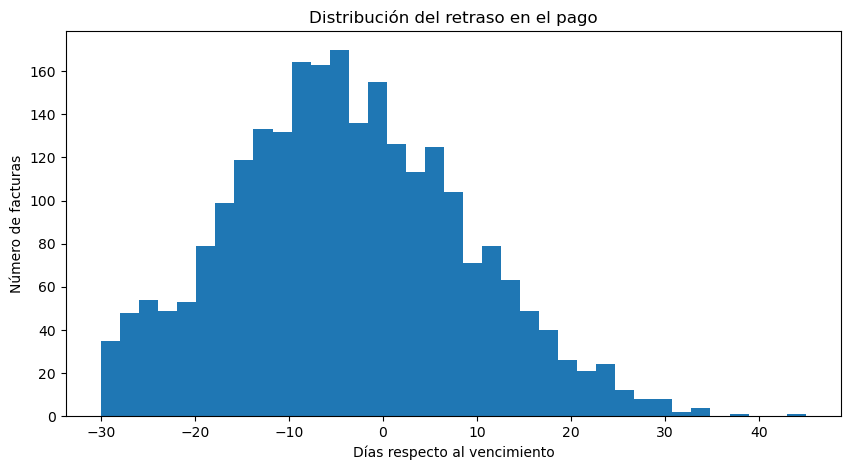

In [22]:
plt.figure(figsize=(10, 5))

plt.hist(
    df["days_delay_signed"],
    bins=37
)

plt.xlabel("Días respecto al vencimiento")
plt.ylabel("Número de facturas")
plt.title("Distribución del retraso en el pago")

plt.show()

#### Creamos buckets

- Segmetamos los retrasos
- En función de la distribución decidiremos si el target sera un retraso mayor a 0, 5 o 10 días

In [23]:
bins = [-np.inf, 0, 5, 10, 15, 30, np.inf]

labels = [
    "Puntual/anticipado",
    "1-5 días",
    "6-10 días",
    "11-15 días",
    "16-30 días",
    ">30 días"
]

df["delay_bucket"] = pd.cut(
    df["days_delay_signed"],
    bins=bins,
    labels=labels
)

df["delay_bucket"].value_counts().sort_index()

delay_bucket
Puntual/anticipado    1589
1-5 días               308
6-10 días              231
11-15 días             164
16-30 días             166
>30 días                 8
Name: count, dtype: int64

In [24]:
df["delay_bucket"].value_counts(normalize=True).sort_index() * 100

delay_bucket
Puntual/anticipado    64.436334
1-5 días              12.489862
6-10 días              9.367397
11-15 días             6.650446
16-30 días             6.731549
>30 días               0.324412
Name: proportion, dtype: float64

- Establecemos como target principal `late_payment = days_delay_signed > 0`.
- Como experimento secundario podría estudiarse `days_delay_signed > 5`, ya que todavía existen 569 casos positivos (aproximadamente el 23 % del dataset). Este umbral puede tener mayor interés empresarial porque un retraso de uno o dos días no necesariamente requiere la misma intervención que un retraso más prolongado.
- Los retrasos superiores a 30 días no se utilizarán como target porque solo existen 8 casos positivos.

### Análisis de clientes

In [25]:
# Número de clientes único
df['customerID'].nunique()

100

In [26]:
# Agrupamos clientes por número de facturas
invoices_per_customer =(
    df.groupby("customerID")
    .size()
    .sort_values(ascending=False)
)

invoices_per_customer.describe()

count    100.000000
mean      24.660000
std        4.774131
min       15.000000
25%       21.000000
50%       24.000000
75%       28.000000
max       36.000000
dtype: float64

- Viendo los datos de clientes, podemos reconstruir el comportamiento historico ya que la facturación está distribuida en 100 clientes

##### Distribución de facturas por cliente

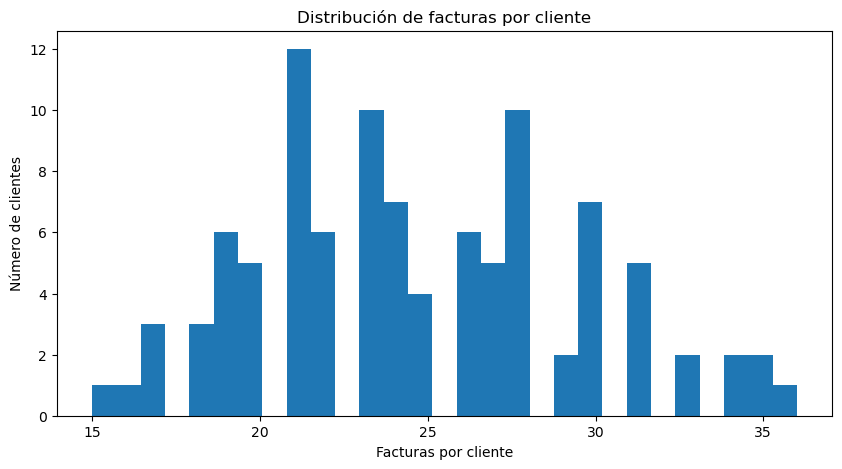

In [27]:
plt.figure(figsize=(10, 5))

plt.hist(
    invoices_per_customer,
    bins=29
)

plt.xlabel("Facturas por cliente")
plt.ylabel("Número de clientes")
plt.title("Distribución de facturas por cliente")

plt.show()

La concentración por cliente es reducida. Los 10 clientes con mayor número de facturas concentran aproximadamente el 13,5 % de las observaciones y los 20 primeros alrededor del 25,7 %.

En términos monetarios, los 10 clientes con mayor importe acumulado representan aproximadamente el 15,7 % del importe total y los 20 primeros alrededor del 28,9 %.

Por tanto, ni el número de observaciones ni el importe están excesivamente concentrados en unos pocos clientes.

### Concentración del dataset (clientes)

In [28]:
customer_share = (invoices_per_customer / invoices_per_customer.sum())
print(customer_share.head(10).sum())
print(customer_share.head(20).sum())

0.13503649635036497
0.25709651257096516


- El 10 % de los clientes con mayor número de facturas concentra el 13,5 % de las facturas y el 20 % concentra aproximadamente el 25,7 %. No existe una concentración excesiva de observaciones en unos pocos clientes.

In [29]:
customer_revenue = (
    df.groupby("customerID")["InvoiceAmount"]
    .sum()
    .sort_values(ascending=False)
)

customer_revenue_share = (
    customer_revenue /
    customer_revenue.sum()
)

print(customer_revenue_share.head(10).sum())
print(customer_revenue_share.head(20).sum())

0.15691341242619156
0.28881896787868755


### Comportamiento de retraso por cliente

Queremos saber:

- ¿hay clientes que siempre pagan tarde?;
- ¿hay clientes que nunca pagan tarde?;
- ¿existen diferencias claras entre clientes?;
- ¿el histórico del cliente probablemente será predictivo?

In [30]:
customer_stats = (
    df.groupby("customerID")
    .agg(
        invoice_count=("invoiceNumber", "count"),
        late_rate=("late_payment", "mean"),
        avg_delay=("days_delay_signed", "mean"),
        max_delay=("days_delay_signed", "max"),
        total_amount=("InvoiceAmount", "sum"),
        avg_amount=("InvoiceAmount", "mean")
    )
)

customer_stats.describe()

,invoice_count,late_rate,avg_delay,max_delay,total_amount,avg_amount
count,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000
mean,24.660000,0.358332,-3.550236,12.690000,1477.031800,59.928826
std,4.774131,0.334869,10.127961,12.574381,450.525572,14.228309
min,15.000000,0.000000,-25.722222,-21.000000,338.280000,17.804211
25%,21.000000,0.057359,-10.648684,3.000000,1186.527500,51.332294
50%,24.000000,0.250000,-3.821429,14.500000,1463.845000,61.890736
75%,28.000000,0.660183,3.471154,22.000000,1770.917500,69.950520
max,36.000000,1.000000,19.533333,45.000000,2646.810000,87.959474


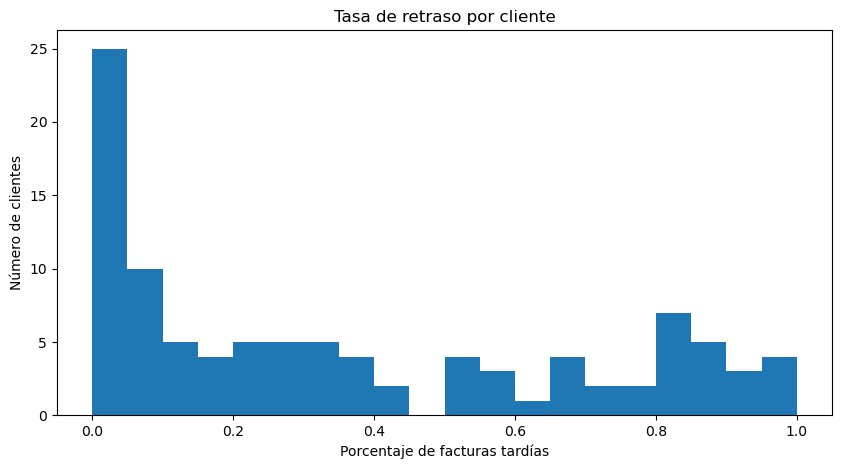

In [31]:
plt.figure(figsize=(10, 5))

plt.hist(
    customer_stats["late_rate"],
    bins=20
)

plt.xlabel("Porcentaje de facturas tardías")
plt.ylabel("Número de clientes")
plt.title("Tasa de retraso por cliente")

plt.show()

- bastantes clientes cerca de 0 % de retrasos
- clientes intermedios
- otro grupo con tasas cercanas a 80–100 %
- El cliente parece tener un comportamiento de pago persistente y diferenciado, por lo que su historial tiene potencial predictivo.

In [32]:
always_on_time = (
    customer_stats["late_rate"] == 0
).sum()

always_late = (
    customer_stats["late_rate"] == 1
).sum()

print("Clientes sin retrasos:", always_on_time)
print("Clientes siempre tardíos:", always_late)

Clientes sin retrasos: 17
Clientes siempre tardíos: 1


In [33]:
customer_stats

,invoice_count,late_rate,avg_delay,max_delay,total_amount,avg_amount
customerID,,,,,,
0187-ERLSR,16,0.000000,-17.062500,-3,1072.63,67.039375
0379-NEVHP,27,0.037037,-12.555556,17,1584.18,58.673333
0465-DTULQ,26,0.538462,3.730769,21,1360.12,52.312308
0625-TNJFG,28,0.178571,-5.250000,11,1627.26,58.116429
0688-XNJRO,34,0.941176,14.382353,34,1231.45,36.219118
...,...,...,...,...,...,...
9758-AIEIK,21,0.190476,-8.952381,11,1295.38,61.684762
9771-QTLGZ,22,0.000000,-12.500000,-2,1152.95,52.406818
9841-XLGBV,20,0.100000,-4.250000,9,885.25,44.262500


In [34]:
df = df.sort_values(
    ["customerID", "InvoiceDate", "invoiceNumber"]
).copy()

df["customer_previous_settled_count"] = 0
df["customer_previous_late_rate"] = np.nan
df["customer_previous_avg_delay"] = np.nan
df["open_invoice_count_at_issue"] = 0

for customer_id, group in df.groupby("customerID"):

    for idx, row in group.iterrows():

        previous_issued = group[
            group["InvoiceDate"] < row["InvoiceDate"]
        ]

        known_payments = previous_issued[
            previous_issued["SettledDate"] < row["InvoiceDate"]
        ]

        open_invoices = previous_issued[
            previous_issued["SettledDate"] >= row["InvoiceDate"]
        ]

        df.loc[
            idx,
            "customer_previous_settled_count"
        ] = len(known_payments)

        df.loc[
            idx,
            "open_invoice_count_at_issue"
        ] = len(open_invoices)

        if len(known_payments) > 0:

            df.loc[
                idx,
                "customer_previous_late_rate"
            ] = known_payments["late_payment"].mean()

            df.loc[
                idx,
                "customer_previous_avg_delay"
            ] = known_payments[
                "days_delay_signed"
            ].mean()

df

,countryCode,customerID,PaperlessDate,invoiceNumber,InvoiceDate,DueDate,InvoiceAmount,Disputed,SettledDate,PaperlessBill,...,DaysLate,days_to_settle_calc,days_delay_signed,days_late_calc,late_payment,delay_bucket,customer_previous_settled_count,customer_previous_late_rate,customer_previous_avg_delay,open_invoice_count_at_issue
991,391,0187-ERLSR,7/31/2013,4037644863,2012-03-29,2012-04-28,62.68,Yes,2012-04-25,Paper,...,0,27,-3,0,0,Puntual/anticipado,0,NaN,NaN,0
2345,391,0187-ERLSR,7/31/2013,9471530987,2012-05-15,2012-06-14,77.19,No,2012-05-28,Paper,...,0,13,-17,0,0,Puntual/anticipado,1,0.000000,-3.000000,0
2401,391,0187-ERLSR,7/31/2013,9744145268,2012-05-21,2012-06-20,51.65,No,2012-06-04,Paper,...,0,14,-16,0,0,Puntual/anticipado,1,0.000000,-3.000000,1
1791,391,0187-ERLSR,7/31/2013,7214076449,2012-06-16,2012-07-16,64.47,Yes,2012-07-04,Paper,...,0,18,-12,0,0,Puntual/anticipado,3,0.000000,-12.000000,0
445,391,0187-ERLSR,7/31/2013,1756742390,2012-09-05,2012-10-05,84.57,No,2012-09-14,Paper,...,0,9,-21,0,0,Puntual/anticipado,4,0.000000,-12.000000,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
858,770,9928-IJYBQ,3/18/2012,3480606970,2013-05-09,2013-06-08,58.83,No,2013-06-11,Electronic,...,3,33,3,3,1,1-5 días,16,0.812500,3.875000,1
922,770,9928-IJYBQ,3/18/2012,3761658749,2013-05-31,2013-06-30,66.38,No,2013-07-08,Electronic,...,8,38,8,8,1,6-10 días,17,0.823529,4.000000,1
1885,770,9928-IJYBQ,3/18/2012,7642713224,2013-08-24,2013-09-23,53.29,No,2013-09-18,Electronic,...,0,25,-5,0,0,Puntual/anticipado,19,0.842105,4.157895,0
1752,770,9928-IJYBQ,3/18/2012,7074243715,2013-09-03,2013-10-03,69.29,No,2013-10-04,Electronic,...,1,31,1,1,1,1-5 días,19,0.842105,4.157895,1


##### Análisis InvoiceAmount

In [35]:
df["InvoiceAmount"].describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99])

count    2466.000000
mean       59.895856
std        20.435838
min         5.260000
1%         10.160000
5%         24.397500
25%        46.400000
50%        60.560000
75%        73.765000
95%        92.347500
99%       104.195000
max       128.280000
Name: InvoiceAmount, dtype: float64

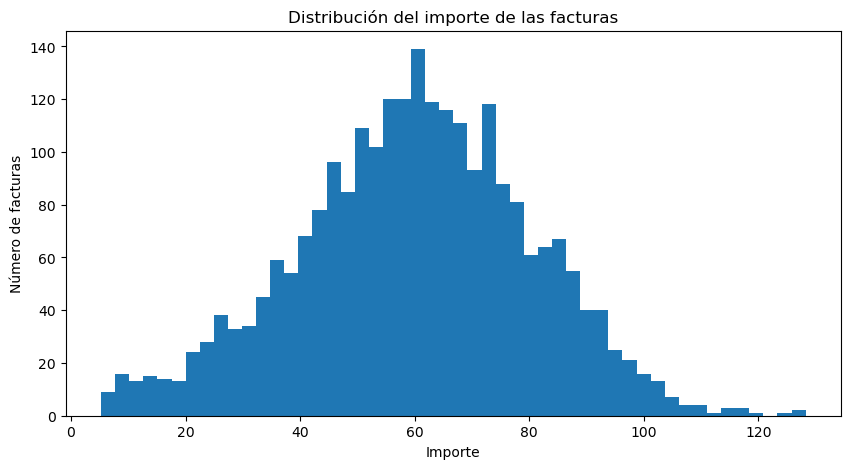

In [36]:
plt.figure(figsize=(10, 5))

plt.hist(
    df["InvoiceAmount"],
    bins=50
)

plt.xlabel("Importe")
plt.ylabel("Número de facturas")
plt.title("Distribución del importe de las facturas")

plt.show()

### Importe y retraso

- ¿Las facturas grandes se retrasan más?

In [37]:
df.groupby("late_payment")["InvoiceAmount"].describe()

,count,mean,std,min,25%,50%,75%,max
late_payment,,,,,,,,
0,1589.0,58.994588,20.255565,5.26,46.32,59.86,72.88,124.38
1,877.0,61.528826,20.670146,7.45,46.86,61.71,75.39,128.28


In [38]:
df["amount_quartile"] = pd.qcut(
    df["InvoiceAmount"],
    q=4,
    duplicates="drop"
)

df.groupby(
    "amount_quartile",
    observed=True
)["late_payment"].mean()

amount_quartile
(5.2589999999999995, 46.4]    0.351133
(46.4, 60.56]                 0.328455
(60.56, 73.765]               0.339286
(73.765, 128.28]              0.403566
Name: late_payment, dtype: float64

- El importe absoluto presenta una relación univariante débil con el retraso, aunque las facturas del cuartil superior muestran una tasa de retraso ligeramente mayor. Se mantendrá inicialmente como variable candidata y se evaluará su utilidad durante el modelado.

### Análisis Disputed

In [39]:
df['Disputed'].value_counts(dropna=False)

Disputed
No     1905
Yes     561
Name: count, dtype: int64

In [40]:
pd.crosstab(
    df['Disputed'],
    df['late_payment'],
    normalize='index'
    )

late_payment,0,1
Disputed,,
No,0.740682,0.259318
Yes,0.317291,0.682709


In [41]:
df.groupby("Disputed")[
    "days_delay_signed"
].describe()

,count,mean,std,min,25%,50%,75%,max
Disputed,,,,,,,,
No,1905.0,-6.493963,10.93939,-30.0,-14.0,-7.0,1.0,34.0
Yes,561.0,6.424242,11.56326,-21.0,-2.0,7.0,14.0,45.0


- La variable Disputed presenta una fuerte asociación con el retraso. Sin embargo, antes de utilizarla como predictor debe confirmarse que este estado era conocido en el momento de emitir la factura. En ausencia de una fecha de disputa, se excluirá inicialmente para evitar fuga de información.

### Análisis PaperlessBill

In [42]:
df["PaperlessBill"].value_counts(dropna=False)

PaperlessBill
Paper         1263
Electronic    1203
Name: count, dtype: int64

In [43]:
pd.crosstab(
    df["PaperlessBill"],
    df["late_payment"],
    normalize="index"
)

late_payment,0,1
PaperlessBill,,
Electronic,0.724855,0.275145
Paper,0.567696,0.432304


In [44]:
df["invoice_year"] = df["InvoiceDate"].dt.year
df["invoice_month"] = df["InvoiceDate"].dt.month
df["invoice_year_month"] = (df["InvoiceDate"].dt.to_period("M"))

- Las facturas en formato físico parecen tener mayor probabilidad de retraso en el pago

In [45]:
pd.crosstab(
    df["invoice_year"],
    df["PaperlessBill"],
    normalize="index"
)

PaperlessBill,Electronic,Paper
invoice_year,,
2012,0.24354,0.75646
2013,0.75021,0.24979


In [46]:
df.groupby(
    ["invoice_year", "PaperlessBill"]
)["late_payment"].mean()

invoice_year  PaperlessBill
2012          Electronic       0.295820
              Paper            0.421325
2013          Electronic       0.267937
              Paper            0.468013
Name: late_payment, dtype: float64

### Análisis countryCode

In [47]:
df["countryCode"].value_counts(dropna=False)

countryCode
391    616
406    561
770    506
897    396
818    387
Name: count, dtype: int64

In [48]:
pd.crosstab(
    df["countryCode"],
    df["late_payment"],
    normalize="index"
)

late_payment,0,1
countryCode,,
391,0.745130,0.254870
406,0.584670,0.415330
770,0.612648,0.387352
818,0.586563,0.413437
897,0.669192,0.330808


In [49]:
df.groupby("countryCode")["days_delay_signed"].agg([
    "count",
    "mean",
    "median",
    "max"
])

,count,mean,median,max
countryCode,,,,
391,616,-6.551948,-7.0,24
406,561,-2.406417,-2.0,45
770,506,-1.839921,-3.0,34
818,387,-1.204134,-2.0,34
897,396,-5.010101,-6.0,34


- Cuidado, aqui el countryCode está como número, hay que cambiar el formato a object o string ya que el modelo puede tomarlo como variable numérica cuando no es así

### Comportamiento temporal

- Segmentamos las fechas en años y meses para obserbar si hay cambios en el tiempo
- ¿En qué meses hay mayor o menor volumen de facturación?
- evolución temporal
- volumen monetario acumulado de cada mes

In [50]:
df["invoice_year"] = df["InvoiceDate"].dt.year
df["invoice_month"] = df["InvoiceDate"].dt.month
df["invoice_year_month"] = (df["InvoiceDate"].dt.to_period("M"))

In [51]:
monthly = (
    df
    .groupby(
        pd.Grouper(
            key="InvoiceDate",
            freq="MS"
        )
    )
    .agg(
        invoices=("invoiceNumber", "count"),
        total_amount=("InvoiceAmount", "sum"),
        late_rate=("late_payment", "mean"),
        avg_delay=("days_delay_signed", "mean")
    )
    .reset_index()
)

monthly["month_label"] = (
    monthly["InvoiceDate"]
    .dt.strftime("%m/%Y")
)

monthly

,InvoiceDate,invoices,total_amount,late_rate,avg_delay,month_label
0,2012-01-01,90,5658.82,0.455556,0.466667,01/2012
1,2012-02-01,97,5929.06,0.432990,-1.340206,02/2012
2,2012-03-01,117,6730.54,0.384615,-1.008547,03/2012
3,2012-04-01,97,6005.03,0.422680,0.123711,04/2012
4,2012-05-01,112,6841.39,0.392857,-2.946429,05/2012
5,2012-06-01,98,5575.30,0.418367,-1.469388,06/2012
6,2012-07-01,109,6575.38,0.385321,-1.990826,07/2012
7,2012-08-01,102,6105.54,0.372549,-3.362745,08/2012
8,2012-09-01,122,6989.89,0.401639,-2.426230,09/2012
9,2012-10-01,108,6623.76,0.296296,-3.962963,10/2012


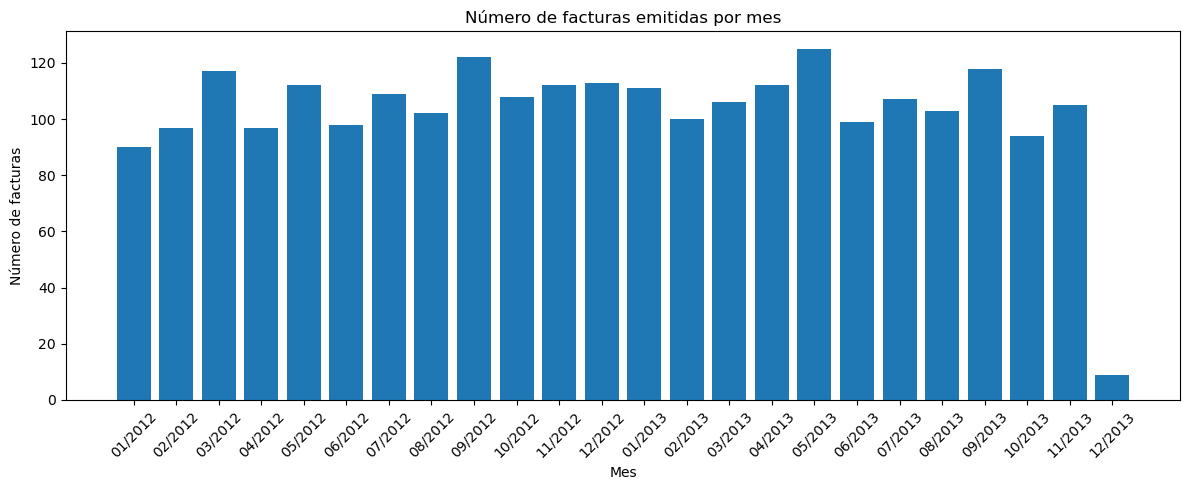

In [52]:
fig, ax = plt.subplots(figsize=(12, 5))

ax.bar(
    monthly["month_label"],
    monthly["invoices"]
)

ax.set_title("Número de facturas emitidas por mes")
ax.set_xlabel("Mes")
ax.set_ylabel("Número de facturas")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

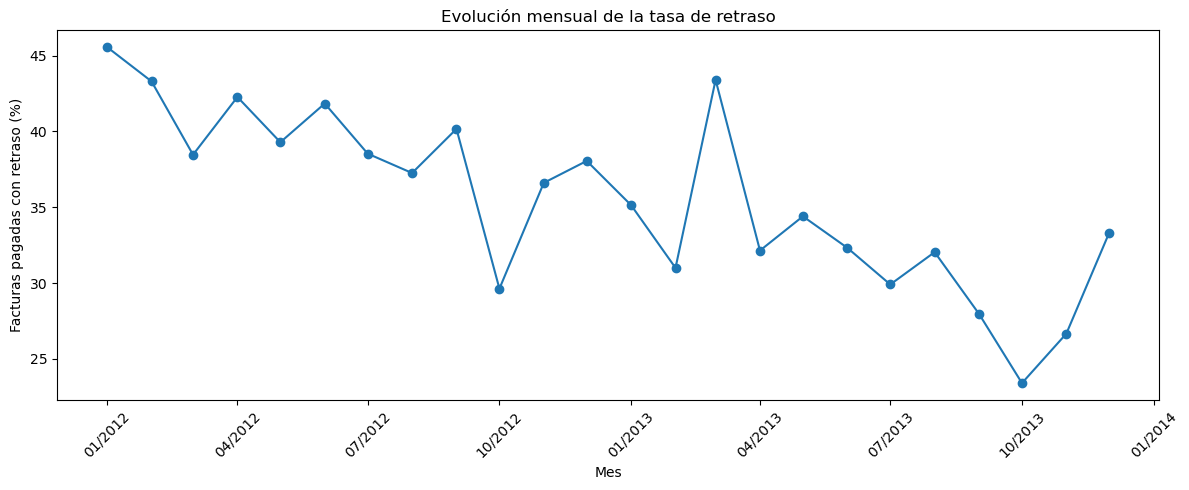

In [53]:
import matplotlib.dates as mdates

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(
    monthly["InvoiceDate"],
    monthly["late_rate"] * 100,
    marker="o"
)

ax.set_title("Evolución mensual de la tasa de retraso")
ax.set_xlabel("Mes")
ax.set_ylabel("Facturas pagadas con retraso (%)")

ax.xaxis.set_major_formatter(
    mdates.DateFormatter("%m/%Y")
)

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

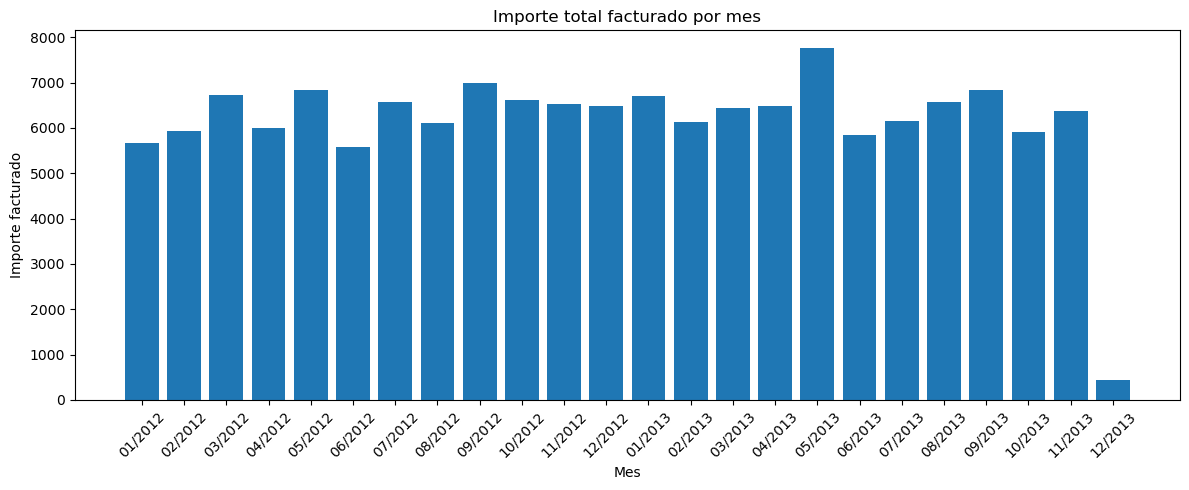

In [54]:
fig, ax = plt.subplots(figsize=(12, 5))

ax.bar(
    monthly["month_label"],
    monthly["total_amount"]
)

ax.set_title("Importe total facturado por mes")
ax.set_xlabel("Mes")
ax.set_ylabel("Importe facturado")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

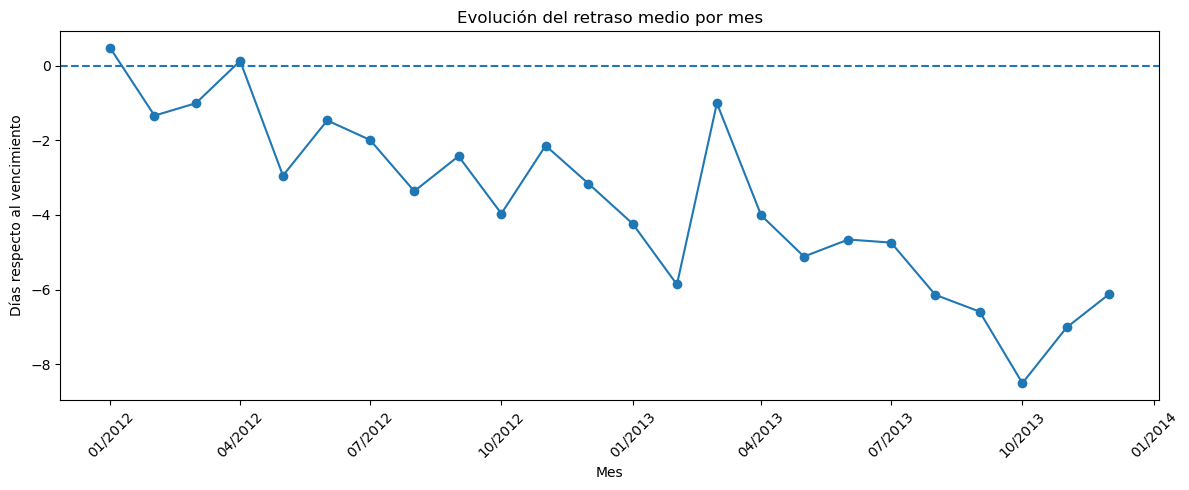

In [55]:
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(
    monthly["InvoiceDate"],
    monthly["avg_delay"],
    marker="o"
)

ax.axhline(
    0,
    linestyle="--"
)

ax.set_title("Evolución del retraso medio por mes")
ax.set_xlabel("Mes")
ax.set_ylabel("Días respecto al vencimiento")

ax.xaxis.set_major_formatter(
    mdates.DateFormatter("%m/%Y")
)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

- El comportamiento de pago no es completamente estacionario y presenta una mejora a lo largo del tiempo.
- El último mes del histórico es incompleto, ya que la última factura disponible corresponde al 2 de diciembre de 2013. Por ello diciembre de 2013 se excluye de las conclusiones sobre volumen mensual.
- **Tasa de retraso**: Existe una clara tendencia descendente, aunque con variaciones y algún repunte como marzo de 2013.

### Plazo de pago

In [56]:
df["payment_term_days"] = (df["DueDate"] - df["InvoiceDate"]).dt.days

df["payment_term_days"].value_counts()

payment_term_days
30    2466
Name: count, dtype: int64

- Ahora sabemos que el plazo de pago no aporta información al modelo ya que siempre es el mismo

### Histórico de clientes

- ¿Qué porcentaje de facturas pertenece a clientes de los que ya conocemos suficiente histórico?

In [57]:
df = df.sort_values(["customerID", "InvoiceDate"])

In [58]:
df["previous_invoice_count"] = (
    df.groupby("customerID").cumcount()
)

df["previous_invoice_count"].describe()

count    2466.000000
mean       12.287510
std         7.882586
min         0.000000
25%         6.000000
50%        12.000000
75%        18.000000
max        35.000000
Name: previous_invoice_count, dtype: float64

In [59]:
print((df["previous_invoice_count"] == 0).mean())
print((df["previous_invoice_count"] >= 3).mean())
print((df["previous_invoice_count"] >= 5).mean())

0.040551500405515
0.878345498783455
0.797242497972425


In [60]:
historical_availability = pd.Series({
    "Sin pagos anteriores conocidos": (
        df["customer_previous_settled_count"] == 0
    ).mean(),

    "Al menos 1 pago conocido": (
        df["customer_previous_settled_count"] >= 1
    ).mean(),

    "Al menos 3 pagos conocidos": (
        df["customer_previous_settled_count"] >= 3
    ).mean(),

    "Al menos 5 pagos conocidos": (
        df["customer_previous_settled_count"] >= 5
    ).mean()
}) * 100

historical_availability.round(2)

Sin pagos anteriores conocidos     7.87
Al menos 1 pago conocido          92.13
Al menos 3 pagos conocidos        83.74
Al menos 5 pagos conocidos        75.63
dtype: float64

In [61]:
df[
    [
        "customer_previous_settled_count",
        "open_invoice_count_at_issue",
        "customer_previous_late_rate",
        "customer_previous_avg_delay"
    ]
].describe()

,customer_previous_settled_count,open_invoice_count_at_issue,customer_previous_late_rate,customer_previous_avg_delay
count,2466.000000,2466.000000,2272.000000,2272.000000
mean,11.358070,0.912003,0.381475,-2.272817
std,7.837415,0.988761,0.365167,10.053774
min,0.000000,0.000000,0.000000,-28.000000
25%,5.000000,0.000000,0.000000,-9.000000
50%,11.000000,1.000000,0.272727,-2.409091
75%,17.000000,1.000000,0.700000,5.500000
max,34.000000,6.000000,1.000000,31.000000


In [62]:
print("Facturas sin ningún pago histórico conocido:",(df["customer_previous_settled_count"] == 0).sum())

print("Facturas con alguna factura pendiente al emitirse:",(df["open_invoice_count_at_issue"] > 0).sum())

print("Porcentaje con alguna factura pendiente:",(df["open_invoice_count_at_issue"] > 0).mean() * 100)

Facturas sin ningún pago histórico conocido: 194
Facturas con alguna factura pendiente al emitirse: 1429
Porcentaje con alguna factura pendiente: 57.94809407948094


### Disponibilidad real de histórico

El número de facturas anteriores emitidas no es suficiente para determinar qué información estaría disponible al realizar una predicción.

Por este motivo se distingue entre:

- facturas anteriores emitidas;
- facturas anteriores cuyo pago ya había finalizado;
- facturas anteriores que todavía estaban abiertas.

Para construir variables como `customer_previous_late_rate` únicamente podrán utilizarse facturas cuyo resultado ya fuese conocido en la fecha de emisión de la factura actual.

El análisis de `customer_previous_settled_count` permite comprobar qué proporción del dataset dispone realmente de suficiente histórico conocido para construir estas variables sin fuga de información.

### Viabilidad split temporal

In [63]:
df_sorted = df.sort_values("InvoiceDate")

In [64]:
unique_dates = np.sort(
    df["InvoiceDate"].dropna().unique()
)

train_cut_idx = int(
    len(unique_dates) * 0.70
)

val_cut_idx = int(
    len(unique_dates) * 0.85
)

train_cutoff = unique_dates[train_cut_idx]
val_cutoff = unique_dates[val_cut_idx]

train = df[
    df["InvoiceDate"] < train_cutoff
]

validation = df[
    (df["InvoiceDate"] >= train_cutoff)
    & (df["InvoiceDate"] < val_cutoff)
]

test = df[
    df["InvoiceDate"] >= val_cutoff
]

for name, part in {
    "train": train,
    "validation": validation,
    "test": test
}.items():

    print(
        f"{name:10s}",
        f"n={len(part):4d}",
        f"desde={part['InvoiceDate'].min().date()}",
        f"hasta={part['InvoiceDate'].max().date()}",
        f"late_rate={part['late_payment'].mean():.2%}"
    )

train      n=1719 desde=2012-01-03 hasta=2013-05-04 late_rate=38.16%
validation n= 381 desde=2013-05-05 hasta=2013-08-19 late_rate=32.55%
test       n= 366 desde=2013-08-20 hasta=2013-12-02 late_rate=26.50%


### Outliers

In [65]:
outlier_cols = [
    "InvoiceAmount",
    "days_to_settle_calc",
    "days_delay_signed",
    "days_late_calc"
]

df[outlier_cols].describe(percentiles=[0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99]).T

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
InvoiceAmount,2466.0,59.895856,20.435838,5.26,10.16,24.3975,46.4,60.56,73.765,92.3475,104.195,128.28
days_to_settle_calc,2466.0,26.444850,12.334930,0.00,2.00,6.0000,18.0,26.00,35.000,48.0000,56.000,75.00
days_delay_signed,2466.0,-3.555150,12.334930,-30.00,-28.00,-24.0000,-12.0,-4.00,5.000,18.0000,26.000,45.00
days_late_calc,2466.0,3.442417,6.290607,0.00,0.00,0.0000,0.0,0.00,5.000,18.0000,26.000,45.00


In [66]:
def iqr_summary(data, columns):
    results = []

    for col in columns:
        q1 = data[col].quantile(0.25)
        q3 = data[col].quantile(0.75)

        iqr = q3 - q1

        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr

        mask = (
            (data[col] < lower)
            | (data[col] > upper)
        )

        results.append({
            "variable": col,
            "q1": q1,
            "q3": q3,
            "iqr": iqr,
            "lower_bound": lower,
            "upper_bound": upper,
            "outlier_count": mask.sum(),
            "outlier_pct": mask.mean() * 100
        })

    return pd.DataFrame(results)

In [67]:
outlier_summary = iqr_summary(
    df,
    outlier_cols
)

outlier_summary

,variable,q1,q3,iqr,lower_bound,upper_bound,outlier_count,outlier_pct
0,InvoiceAmount,46.4,73.765,27.365,5.3525,114.8125,8,0.324412
1,days_to_settle_calc,18.0,35.000,17.000,-7.5000,60.5000,8,0.324412
2,days_delay_signed,-12.0,5.000,17.000,-37.5000,30.5000,8,0.324412
3,days_late_calc,0.0,5.000,5.000,-7.5000,12.5000,259,10.502839


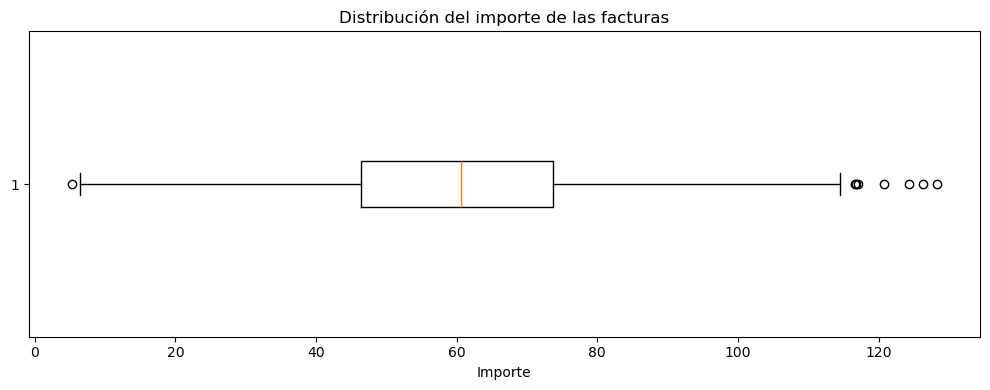

In [68]:
plt.figure(figsize=(10, 4))

plt.boxplot(
    df["InvoiceAmount"].dropna(),
    vert=False
)

plt.title("Distribución del importe de las facturas")
plt.xlabel("Importe")

plt.tight_layout()
plt.show()

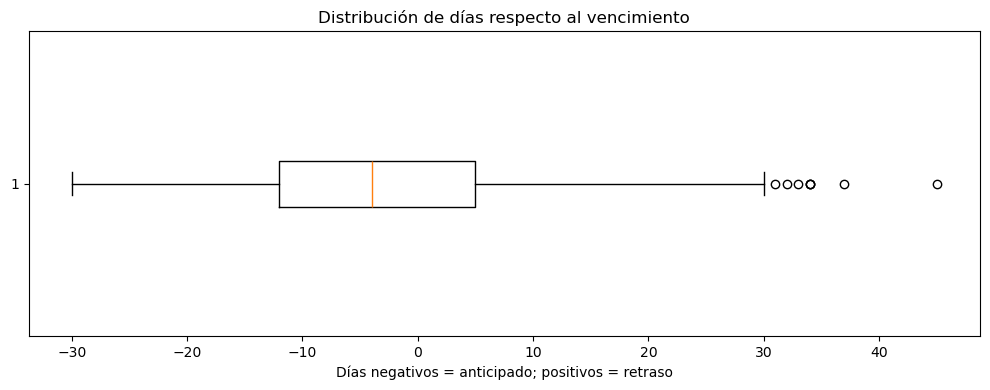

In [69]:
plt.figure(figsize=(10, 4))

plt.boxplot(
    df["days_delay_signed"].dropna(),
    vert=False
)

plt.title(
    "Distribución de días respecto al vencimiento"
)
plt.xlabel(
    "Días negativos = anticipado; positivos = retraso"
)

plt.tight_layout()
plt.show()

- days_late_calc tiene una distribución con una gran masa en cero, por lo que IQR no es especialmente adecuado para decidir qué eliminar.

In [70]:
df.nlargest(
    10,
    "InvoiceAmount"
)[
    [
        "invoiceNumber",
        "customerID",
        "InvoiceDate",
        "InvoiceAmount",
        "days_delay_signed"
    ]
]

,invoiceNumber,customerID,InvoiceDate,InvoiceAmount,days_delay_signed
2379,9632048192,1080-NDGAE,2012-07-09,128.28,15
2432,9858844250,5164-VMYWJ,2013-03-27,126.31,10
187,685917930,9725-EZTEJ,2012-10-13,124.38,-2
1747,7043895839,7329-TWKLF,2012-05-02,120.76,-8
1534,6211621442,3831-FXWYK,2012-03-03,117.01,18
143,555108669,9725-EZTEJ,2012-05-02,116.78,-9
2083,8401420623,1447-YZKCL,2013-07-19,116.66,10
524,2118879684,9322-YCTQO,2013-09-06,114.54,5
1535,6215256535,6632-CGYHU,2013-07-04,114.44,-19
72,273425635,5924-UOPGH,2012-02-07,113.76,11


In [71]:
df.nlargest(
    10,
    "days_delay_signed"
)[
    [
        "invoiceNumber",
        "customerID",
        "InvoiceDate",
        "InvoiceAmount",
        "days_delay_signed"
    ]
]

,invoiceNumber,customerID,InvoiceDate,InvoiceAmount,days_delay_signed
1882,7619716138,2621-XCLEH,2012-11-18,86.39,45
2307,9275623026,9117-LYRCE,2012-07-27,69.95,37
2113,8493182849,0688-XNJRO,2012-01-18,18.03,34
614,2527171256,4460-ZXNDN,2013-04-22,75.16,34
1327,5364802553,9181-HEKGV,2012-12-30,87.00,34
907,3706686871,9181-HEKGV,2012-04-16,88.84,33
655,2698045799,0688-XNJRO,2013-03-26,55.16,32
1607,6482427308,2621-XCLEH,2012-01-13,80.99,31
268,1012251297,1408-OQZUE,2012-02-21,26.05,30
1100,4456170015,2621-XCLEH,2012-06-27,69.42,30


In [72]:
df.nsmallest(
    10,
    "days_delay_signed"
)[
    [
        "invoiceNumber",
        "customerID",
        "InvoiceDate",
        "InvoiceAmount",
        "days_delay_signed"
    ]
]

,invoiceNumber,customerID,InvoiceDate,InvoiceAmount,days_delay_signed
1375,5584805665,3271-HYHDN,2013-07-23,71.02,-30
98,367399005,3271-HYHDN,2013-08-10,58.78,-30
1894,7679449609,9286-VLKMI,2013-03-06,47.39,-30
1909,7722226334,9286-VLKMI,2013-06-10,51.55,-30
106,385813290,2820-XGXSB,2012-05-07,73.90,-29
1738,6988048839,4092-ZAVRG,2012-06-05,71.60,-29
1497,6053161771,4092-ZAVRG,2013-02-10,73.56,-29
1337,5404048854,4092-ZAVRG,2013-08-07,73.08,-29
456,1801620782,4092-ZAVRG,2013-08-14,78.44,-29
90,320318018,5284-DJOZO,2013-03-23,80.71,-29


In [73]:
# Control de inconsistencias
quality_checks = {
    "invoice_amount_le_0": (
        df["InvoiceAmount"] <= 0
    ).sum(),

    "due_before_invoice": (
        df["DueDate"] < df["InvoiceDate"]
    ).sum(),

    "settled_before_invoice": (
        df["SettledDate"] < df["InvoiceDate"]
    ).sum(),

    "negative_payment_term": (
        df["payment_term_days"] < 0
    ).sum()
}

quality_checks

{'invoice_amount_le_0': 0,
 'due_before_invoice': 0,
 'settled_before_invoice': 0,
 'negative_payment_term': 0}

### Correlaciones

In [74]:
numeric_cols = [
    "InvoiceAmount",
    "payment_term_days",
    "days_to_settle_calc",
    "days_delay_signed"
]

df[numeric_cols].corr()

,InvoiceAmount,payment_term_days,days_to_settle_calc,days_delay_signed
InvoiceAmount,1.000000,NaN,0.060786,0.060786
payment_term_days,NaN,NaN,NaN,NaN
days_to_settle_calc,0.060786,NaN,1.000000,1.000000
days_delay_signed,0.060786,NaN,1.000000,1.000000


In [75]:
df[numeric_cols].corr().describe()

,InvoiceAmount,payment_term_days,days_to_settle_calc,days_delay_signed
count,3.000000,0.0,3.000000,3.000000
mean,0.373858,NaN,0.686929,0.686929
std,0.542255,NaN,0.542255,0.542255
min,0.060786,NaN,0.060786,0.060786
25%,0.060786,NaN,0.530393,0.530393
50%,0.060786,NaN,1.000000,1.000000
75%,0.530393,NaN,1.000000,1.000000
max,1.000000,NaN,1.000000,1.000000


La matriz de correlaciones se utiliza únicamente como análisis descriptivo.

No debe utilizarse para seleccionar predictores en este momento, ya que `days_to_settle_calc` y `days_delay_signed` contienen información del resultado final, mientras que `payment_term_days` es constante.

La correlación perfecta entre `days_to_settle_calc` y `days_delay_signed` se explica porque todas las facturas tienen un vencimiento de 30 días:

`days_to_settle_calc = days_delay_signed + 30`.

## Análisis de `PaperlessDate`

La variable `PaperlessDate` parece representar la fecha a partir de la cual un cliente pasa a utilizar facturación electrónica. Antes de utilizarla como variable predictora es necesario comprobar:

- si tiene un valor consistente por cliente;
- su relación con `PaperlessBill`;
- si puede contener información posterior a la fecha de emisión de la factura;
- si su efecto sobre el retraso puede estar confundido con la evolución temporal del dataset.

In [76]:
df.dtypes

countryCode                                 int64
customerID                                 object
PaperlessDate                              object
invoiceNumber                               int64
InvoiceDate                        datetime64[ns]
DueDate                            datetime64[ns]
InvoiceAmount                             float64
Disputed                                   object
SettledDate                        datetime64[ns]
PaperlessBill                              object
DaysToSettle                                int64
DaysLate                                    int64
days_to_settle_calc                         int64
days_delay_signed                           int64
days_late_calc                              int64
late_payment                                int32
delay_bucket                             category
customer_previous_settled_count             int64
customer_previous_late_rate               float64
customer_previous_avg_delay               float64


In [77]:
df["PaperlessDate"] = pd.to_datetime(
    df["PaperlessDate"],
    format="%m/%d/%Y",
    errors="coerce"
)

In [78]:
paperless_df = df[
    [
        "customerID",
        "invoiceNumber",
        "InvoiceDate",
        "PaperlessDate",
        "PaperlessBill",
        "late_payment"
    ]
].copy()

print("Tipo:", paperless_df["PaperlessDate"].dtype)
print("Nulos:", paperless_df["PaperlessDate"].isna().sum())
print("Rango:", paperless_df["PaperlessDate"].min(), "-", paperless_df["PaperlessDate"].max())

paperless_df.head()

Tipo: datetime64[ns]
Nulos: 0
Rango: 2012-01-09 00:00:00 - 2013-11-27 00:00:00


,customerID,invoiceNumber,InvoiceDate,PaperlessDate,PaperlessBill,late_payment
991,0187-ERLSR,4037644863,2012-03-29,2013-07-31,Paper,0
2345,0187-ERLSR,9471530987,2012-05-15,2013-07-31,Paper,0
2401,0187-ERLSR,9744145268,2012-05-21,2013-07-31,Paper,0
1791,0187-ERLSR,7214076449,2012-06-16,2013-07-31,Paper,0
445,0187-ERLSR,1756742390,2012-09-05,2013-07-31,Paper,0


In [79]:
paperless_dates_per_customer = (
    paperless_df
    .groupby("customerID")["PaperlessDate"]
    .nunique()
)

print(
    "Clientes con más de una PaperlessDate:",
    (paperless_dates_per_customer > 1).sum()
)

paperless_dates_per_customer.value_counts().sort_index()

Clientes con más de una PaperlessDate: 0


PaperlessDate
1    100
Name: count, dtype: int64

- `PaperlessDate` representa una fecha de cambio de modalidad del cliente, no una característica propia de cada factura.

Relacion entre `PaperlessDate`e `InvoiceDate`

In [80]:
paperless_df["days_invoice_vs_paperless"] = (
    paperless_df["InvoiceDate"]
    - paperless_df["PaperlessDate"]
).dt.days

paperless_df["days_invoice_vs_paperless"].describe()

count    2466.000000
mean       -5.031630
std       269.048094
min      -694.000000
25%      -201.000000
50%        -9.000000
75%       193.000000
max       676.000000
Name: days_invoice_vs_paperless, dtype: float64

In [81]:
print(
    "Facturas emitidas ANTES de PaperlessDate:",
    (paperless_df["InvoiceDate"] < paperless_df["PaperlessDate"]).sum()
)

print(
    "Facturas emitidas EN PaperlessDate:",
    (paperless_df["InvoiceDate"] == paperless_df["PaperlessDate"]).sum()
)

print(
    "Facturas emitidas DESPUÉS de PaperlessDate:",
    (paperless_df["InvoiceDate"] > paperless_df["PaperlessDate"]).sum()
)

Facturas emitidas ANTES de PaperlessDate: 1259
Facturas emitidas EN PaperlessDate: 4
Facturas emitidas DESPUÉS de PaperlessDate: 1203


Si para muchas facturas: PaperlessDate > InvoiceDate, significa que en la fecha de emisión de esa factura estamos utilizando una fecha futura.

Por tanto, la fecha exacta PaperlessDate no debería entrar en X.

Comprobar si `PaperlessBill` se deriva de `PaperlessDate`

In [82]:
paperless_df["paperless_bill_norm"] = (
    paperless_df["PaperlessBill"]
    .astype(str)
    .str.strip()
    .str.lower()
)

paperless_df["expected_ge"] = np.where(
    paperless_df["InvoiceDate"]
    >= paperless_df["PaperlessDate"],
    "electronic",
    "paper"
)

paperless_df["expected_gt"] = np.where(
    paperless_df["InvoiceDate"]
    > paperless_df["PaperlessDate"],
    "electronic",
    "paper"
)

match_ge = (
    paperless_df["paperless_bill_norm"]
    == paperless_df["expected_ge"]
).mean()

match_gt = (
    paperless_df["paperless_bill_norm"]
    == paperless_df["expected_gt"]
).mean()

print(
    f"Coincidencia usando InvoiceDate >= PaperlessDate: "
    f"{match_ge:.2%}"
)

print(
    f"Coincidencia usando InvoiceDate > PaperlessDate: "
    f"{match_gt:.2%}"
)

Coincidencia usando InvoiceDate >= PaperlessDate: 99.84%
Coincidencia usando InvoiceDate > PaperlessDate: 100.00%


`PaperlessBill` y retraso

In [83]:
paperless_late = pd.crosstab(
    paperless_df["PaperlessBill"],
    paperless_df["late_payment"],
    normalize="index"
) * 100

paperless_late

late_payment,0,1
PaperlessBill,,
Electronic,72.485453,27.514547
Paper,56.769596,43.230404


¿Puede existir un efecto temporal?

In [84]:
paperless_by_year = (
    paperless_df
    .assign(
        invoice_year=
        paperless_df["InvoiceDate"].dt.year
    )
    .groupby(
        ["invoice_year", "PaperlessBill"]
    )
    .agg(
        invoices=("invoiceNumber", "count"),
        late_rate=("late_payment", "mean")
    )
)

paperless_by_year["late_rate"] *= 100

paperless_by_year

invoices  late_rate
invoice_year PaperlessBill                     
2012         Electronic          311  29.581994
             Paper               966  42.132505
2013         Electronic          892  26.793722
             Paper               297  46.801347

Evolución mensual de la facturación electrónica

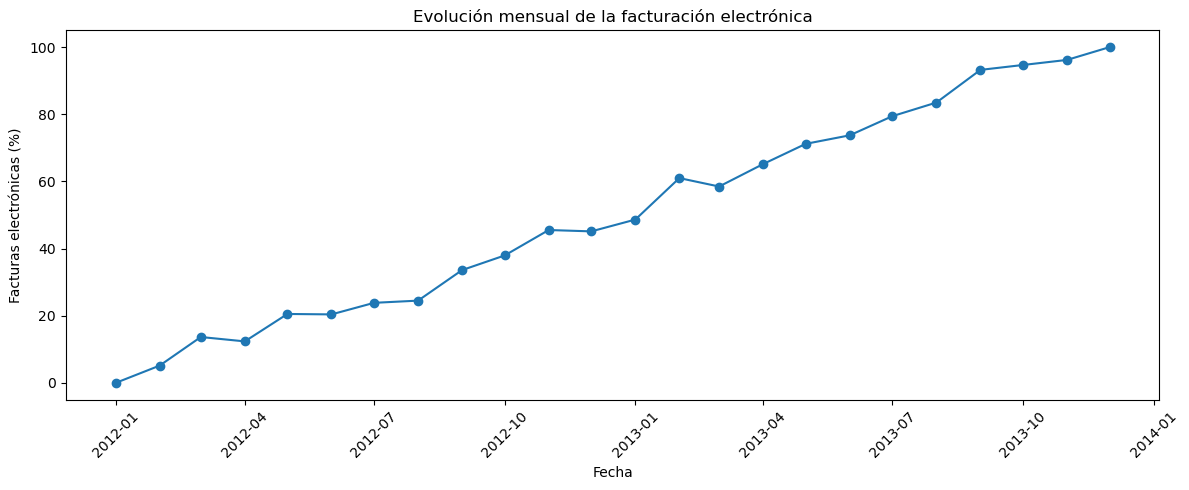

In [85]:
paperless_monthly = (
    paperless_df
    .assign(
        electronic=(
            paperless_df["paperless_bill_norm"]
            == "electronic"
        ).astype(int)
    )
    .groupby(
        pd.Grouper(
            key="InvoiceDate",
            freq="MS"
        )
    )
    .agg(
        electronic_rate=("electronic", "mean")
    )
    .reset_index()
)

paperless_monthly["electronic_rate"] *= 100

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(
    paperless_monthly["InvoiceDate"],
    paperless_monthly["electronic_rate"],
    marker="o"
)

ax.set_title(
    "Evolución mensual de la facturación electrónica"
)

ax.set_xlabel("Fecha")
ax.set_ylabel("Facturas electrónicas (%)")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Conclusión sobre `PaperlessBill`

La modalidad de facturación presenta una asociación clara con el retraso. Las facturas en papel muestran una mayor tasa de retraso que las electrónicas.

También existe un importante efecto temporal: la facturación electrónica pasa de representar aproximadamente el 24 % de las facturas en 2012 a alrededor del 75 % en 2013.

Sin embargo, la diferencia en la tasa de retraso entre papel y electrónico se mantiene al analizar cada año por separado:

- en 2012, las facturas en papel presentan aproximadamente un 42 % de retrasos frente a un 30 % de las electrónicas;
- en 2013, las facturas en papel presentan aproximadamente un 47 % de retrasos frente a un 27 % de las electrónicas.

Por tanto, la asociación entre `PaperlessBill` y `late_payment` no parece explicarse únicamente por el cambio temporal, aunque este análisis no permite establecer una relación causal.

`PaperlessBill` se mantendrá como variable candidata para el modelo.

### Conclusión sobre `PaperlessDate`

`PaperlessDate` debe tratarse con precaución. La variable parece representar una fecha de transición del cliente hacia la facturación electrónica y no una característica propia de cada factura.

En aquellas facturas cuya `PaperlessDate` es posterior a `InvoiceDate`, utilizar directamente esta fecha supondría incorporar información futura que todavía no estaría disponible en el momento de emitir la factura.

Además, si `PaperlessBill` puede reconstruirse casi completamente comparando `InvoiceDate` con `PaperlessDate`, ambas variables contienen información redundante.

## Variables excluidas de `X` por diseño

Algunas variables no se utilizarán directamente como predictores aunque estén disponibles en el momento de realizar la predicción.

La exclusión puede deberse a que son identificadores, variables constantes, información redundante o campos que deben transformarse antes de utilizarse.

Excluir una variable en este apartado no significa necesariamente que contenga fuga de información.

In [86]:
excluded_from_X_design = pd.DataFrame(
    [
        {
            "variable": "invoiceNumber",
            "motivo": (
                "Identificador único de factura. "
                "No representa una característica "
                "económica o conductual."
            )
        },
        {
            "variable": "customerID",
            "motivo": (
                "Se utilizará para construir histórico "
                "del cliente, pero no como predictor "
                "directo para evitar que el modelo "
                "memorice identificadores."
            )
        },
        {
            "variable": "InvoiceDate",
            "motivo": (
                "No se utilizará la fecha completa. "
                "Se derivarán variables temporales "
                "como mes, trimestre o día de semana."
            )
        },
        {
            "variable": "DueDate",
            "motivo": (
                "Todas las facturas tienen prácticamente "
                "el mismo plazo de pago. La fecha completa "
                "no se utilizará directamente."
            )
        },
        {
            "variable": "payment_term_days",
            "motivo": (
                "Es constante (30 días), por lo que "
                "no tiene capacidad para diferenciar "
                "unas facturas de otras."
            )
        }
    ]
)

excluded_from_X_design

,variable,motivo
0,invoiceNumber,Identificador único de factura. No representa ...
1,customerID,Se utilizará para construir histórico del clie...
2,InvoiceDate,No se utilizará la fecha completa. Se derivará...
3,DueDate,Todas las facturas tienen prácticamente el mis...
4,payment_term_days,"Es constante (30 días), por lo que no tiene ca..."


## Variables prohibidas como predictores por fuga de información

El modelo pretende estimar el riesgo de retraso en el momento de emisión de una factura.

Por tanto, cualquier información que solo sea conocida después de la emisión o después de producirse el pago no puede utilizarse como predictor.

Incluir estas variables provocaría fuga de información (`data leakage`) y produciría métricas artificialmente elevadas que no podrían reproducirse en un escenario real.

In [87]:
leakage_variables = pd.DataFrame(
    [
        {
            "variable": "SettledDate",
            "motivo": (
                "Fecha real del cobro. "
                "Solo se conoce después del pago."
            ),
            "decision": "EXCLUIR"
        },
        {
            "variable": "DaysToSettle",
            "motivo": (
                "Número de días que finalmente tardó "
                "la factura en cobrarse."
            ),
            "decision": "EXCLUIR"
        },
        {
            "variable": "DaysLate",
            "motivo": (
                "Resultado final del retraso."
            ),
            "decision": "EXCLUIR"
        },
        {
            "variable": "days_to_settle_calc",
            "motivo": (
                "Se calcula utilizando SettledDate."
            ),
            "decision": "EXCLUIR"
        },
        {
            "variable": "days_delay_signed",
            "motivo": (
                "Se calcula como SettledDate - DueDate "
                "y contiene directamente el resultado."
            ),
            "decision": "EXCLUIR"
        },
        {
            "variable": "days_late_calc",
            "motivo": (
                "Se deriva del retraso final observado."
            ),
            "decision": "EXCLUIR"
        },
        {
            "variable": "late_payment",
            "motivo": (
                "Es la variable objetivo y nunca puede "
                "formar parte de X."
            ),
            "decision": "TARGET"
        },
        {
            "variable": "PaperlessDate",
            "motivo": (
                "En algunas facturas puede representar "
                "una fecha posterior a InvoiceDate, por "
                "lo que incorporaría información futura."
            ),
            "decision": "EXCLUIR"
        },
        {
            "variable": "Disputed",
            "motivo": (
                "No existe DisputeDate y no podemos "
                "demostrar que la disputa fuese conocida "
                "en el momento de emisión."
            ),
            "decision": "EXCLUIR EN BASELINE / REVISAR"
        }
    ]
)

leakage_variables

,variable,motivo,decision
0,SettledDate,Fecha real del cobro. Solo se conoce después d...,EXCLUIR
1,DaysToSettle,Número de días que finalmente tardó la factura...,EXCLUIR
2,DaysLate,Resultado final del retraso.,EXCLUIR
3,days_to_settle_calc,Se calcula utilizando SettledDate.,EXCLUIR
4,days_delay_signed,Se calcula como SettledDate - DueDate y contie...,EXCLUIR
5,days_late_calc,Se deriva del retraso final observado.,EXCLUIR
6,late_payment,Es la variable objetivo y nunca puede formar p...,TARGET
7,PaperlessDate,En algunas facturas puede representar una fech...,EXCLUIR
8,Disputed,No existe DisputeDate y no podemos demostrar q...,EXCLUIR EN BASELINE / REVISAR


### Regla para variables históricas del cliente

Las variables históricas del cliente también pueden producir fuga de información si no se calculan correctamente.

Para una factura emitida en una fecha `t`, únicamente podrá utilizarse información de facturas anteriores cuyo resultado ya fuese conocido en `t`.

Por ejemplo, si una factura anterior todavía no había sido cobrada cuando se emitió la factura actual, todavía no se conoce si acabará pagándose tarde y, por tanto, su resultado no puede incorporarse a `customer_previous_late_rate`.

La construcción de estas variables deberá realizarse con lógica temporal `as-of`.

# Conclusiones y decisiones del EDA

El análisis exploratorio permite concluir que el dataset es viable para desarrollar un MVP de predicción del riesgo de retraso en el cobro de facturas, aunque presenta algunas limitaciones que condicionan el alcance del proyecto.

## Calidad y estructura de los datos

El conjunto contiene 2.466 facturas correspondientes a 100 clientes diferentes.

La calidad inicial de los datos es elevada:

- no se han detectado valores nulos en las variables originales relevantes;
- no existen facturas duplicadas;
- los identificadores de factura son únicos;
- no existen vencimientos anteriores a la fecha de emisión;
- no existen liquidaciones anteriores a la emisión;
- no se han encontrado importes iguales o inferiores a cero.

Por tanto, no se han identificado problemas de calidad que impidan continuar con el proyecto.

## Variable objetivo

Aproximadamente el 35,6 % de las facturas se paga después de su fecha de vencimiento y el 64,4 % restante se paga de forma puntual o anticipada.

El dataset presenta por tanto un desequilibrio moderado, pero la clase positiva está suficientemente representada para entrenar inicialmente modelos sin aplicar técnicas de sobremuestreo.

La variable objetivo principal será:

`late_payment = 1` si `SettledDate > DueDate`.

Como análisis alternativo podría estudiarse posteriormente un umbral de retraso superior a 5 días.

Los retrasos superiores a 30 días no constituyen un objetivo viable, ya que existen únicamente unos pocos casos en todo el dataset.

El conjunto tampoco permite predecir impago definitivo, puesto que las facturas disponibles terminan registrando una fecha de liquidación.

## Representación de los clientes

El dataset contiene aproximadamente 25 facturas por cliente de media, con un mínimo cercano a 15 y un máximo cercano a 36.

La distribución de observaciones entre clientes no presenta una concentración extrema.

Además, una proporción elevada de facturas pertenece a clientes con varias operaciones anteriores, lo que hace viable construir variables relacionadas con el comportamiento histórico del cliente.

La tasa de retraso varía considerablemente entre clientes. Existen clientes con un comportamiento de pago prácticamente puntual y otros con tasas de retraso muy elevadas.

Esta heterogeneidad constituye una de las señales más prometedoras del dataset y justifica la futura construcción de variables como:

- número de facturas anteriores;
- tasa histórica de retraso;
- retraso medio histórico;
- retraso máximo histórico;
- número de facturas pendientes en el momento de emisión;
- importe habitual del cliente.

Estas variables deberán calcularse utilizando exclusivamente información que estuviese disponible en la fecha de emisión de cada factura.

## Importe de las facturas

El importe presenta una relación univariante relativamente débil con el retraso.

Sin embargo, las facturas pertenecientes al cuartil superior de importe muestran una tasa de retraso ligeramente superior.

Por este motivo, `InvoiceAmount` se mantendrá inicialmente como variable candidata.

También puede resultar más informativo comparar el importe de cada factura con el importe histórico habitual del propio cliente que utilizar exclusivamente su valor absoluto.

## Variables categóricas

`PaperlessBill` presenta diferencias apreciables en la tasa de retraso entre facturas electrónicas y en papel, por lo que se mantendrá inicialmente como variable candidata.

Sin embargo, la proporción de facturas electrónicas cambia a lo largo del tiempo, por lo que parte de esta relación puede estar asociada a la evolución temporal general del comportamiento de pago.

`PaperlessDate` no se utilizará directamente como predictor. La variable representa una fecha relacionada con la transición hacia facturación electrónica y, para determinadas facturas, puede contener información posterior a la fecha de emisión.

`Disputed` presenta una fuerte asociación con el retraso, pero no existe una fecha que indique cuándo se produjo la disputa. Debido a que no puede garantizarse que esta información estuviese disponible en el momento de emitir la factura, se excluirá inicialmente para evitar fuga de información.

`countryCode` presenta diferencias en comportamiento de pago entre grupos y podrá considerarse como variable categórica. No debe interpretarse como una variable numérica continua.

## Comportamiento temporal

Se observa una reducción de la tasa de retraso a medida que avanza el período analizado.

La tasa de facturas tardías es superior en la parte inicial del histórico y disminuye en los períodos más recientes.

Esta evolución también aparece al realizar una división temporal preliminar, donde la tasa de retraso disminuye entre entrenamiento, validación y test.

Se observa un cambio temporal en la distribución de la variable objetivo, cuya tasa disminuye desde aproximadamente el 38 % en el período de entrenamiento hasta el 26,5 % en el período de test.

Este comportamiento constituye un cambio de distribución temporal y podría existir también concept drift, algo que deberá comprobarse durante la evaluación de los modelos.

Por este motivo, una división aleatoria de entrenamiento y test no sería representativa del uso real del sistema.

La evaluación deberá respetar estrictamente el orden temporal:

pasado → entrenamiento  
período posterior → validación  
período más reciente → test

El último mes del dataset está incompleto, por lo que no debe utilizarse para extraer conclusiones sobre una caída del volumen de facturación.

## Plazos de pago

Todas las facturas presentan un plazo de pago de 30 días.

Como consecuencia, `payment_term_days` tiene varianza cero y no puede aportar capacidad predictiva.

Esta variable se excluirá del modelo.

Esta característica supone también una limitación del dataset, ya que no será posible analizar si diferentes condiciones de pago, como 30, 60 o 90 días, modifican el riesgo de retraso.

## Valores extremos

Se han identificado algunos valores extremos en el importe y en los días de retraso.

No existen evidencias de que estos registros sean errores de datos.

Los retrasos elevados constituyen precisamente casos relevantes para el problema de negocio, por lo que no se eliminarán automáticamente utilizando únicamente criterios estadísticos como el IQR.

La distribución de `days_late_calc` presenta además una gran concentración de valores iguales a cero, por lo que el método IQR etiqueta como extremos numerosos retrasos válidos.

Los outliers se mantendrán inicialmente y su tratamiento se decidirá únicamente si generan problemas durante el modelado.

## Fuga de información

Las siguientes variables no podrán utilizarse como predictores porque contienen información conocida únicamente después del pago:

- `SettledDate`;
- `DaysToSettle`;
- `DaysLate`;
- `days_to_settle_calc`;
- `days_delay_signed`;
- `days_late_calc`.

`late_payment` será exclusivamente la variable objetivo.

Los identificadores `invoiceNumber` y `customerID` tampoco se utilizarán directamente como variables predictoras. `customerID` se utilizará únicamente para reconstruir el comportamiento histórico del cliente.

Las futuras variables históricas deberán calcularse con lógica temporal `as-of`, utilizando únicamente resultados que ya fuesen conocidos en el momento de emitir cada factura.

## Veredicto final

El dataset se considera adecuado para desarrollar un modelo inicial cuyo objetivo sea:

**estimar, en el momento de emisión de una factura, la probabilidad de que sea pagada después de su fecha de vencimiento.**

El dataset no permite construir de forma rigurosa un modelo de impago definitivo.

La parte de mayor potencial predictivo parece encontrarse en el comportamiento histórico de cada cliente, mientras que variables como el importe, modalidad de facturación, país y momento temporal podrán aportar información complementaria.

La disponibilidad de histórico conocido en el momento de emisión es elevada. El 92,1 % de las facturas dispone de al menos un pago anterior ya observado, el 83,7 % dispone de al menos tres y el 75,6 % de al menos cinco.

Además, aproximadamente el 58 % de las facturas se emite mientras el cliente mantiene alguna factura anterior todavía abierta. Esto permitirá construir variables relacionadas con exposición pendiente y comportamiento de pago reciente sin utilizar información futura.

Por tanto, el EDA confirma la viabilidad del proyecto y permite continuar con la construcción posterior del dataset de modelado manteniendo una separación temporal estricta y evitando cualquier fuga de información.